<a href="https://colab.research.google.com/github/BelenUrdangarin/Integrador-Urdangarin---Olivera/blob/main/Olivera_Urdangarin_Integrador_(Pre_entrega_3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Energia renovable

###Objetivo:

El objetivo del proyecto es analizar y predecir cuál es la fuente de energía renovable más adecuada para cada región y continente, en función de variables climáticas, demográficas y económicas, con el fin de orientar estrategias sostenibles de desarrollo energético a nivel regional

Objetivo del modelo - DF de datos climáticos
Clasificar a los países en tres niveles de impacto climático:

Bajo

Medio

Alto

Esto se basará en variables climáticas y de calidad del aire.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [18]:
clim_pais_fil = pd.read_csv("https://raw.githubusercontent.com/BelenUrdangarin/Integrador-Urdangarin---Olivera/refs/heads/main/clim_pais_filtrado.csv", sep=',',on_bad_lines='skip',na_values="..") #Importo los datos
prod_ren_fil = pd.read_csv("https://raw.githubusercontent.com/BelenUrdangarin/Integrador-Urdangarin---Olivera/refs/heads/main/prod_ren_fil.csv", sep=',',on_bad_lines='skip',na_values="..") #Importo los datos
clim_pais_fil.shape

(50488, 15)

In [19]:
print(clim_pais_fil.columns)  # Muestra las columnas disponibles


Index(['country', 'latitude', 'longitude', 'last_updated',
       'temperature_celsius', 'condition_text', 'wind_mph', 'pressure_mb',
       'precip_mm', 'cloud', 'uv_index', 'air_quality_Carbon_Monoxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'continent'],
      dtype='object')


###Selección de variables

La variables seleccionadas (x) serán todas aquellas que podemos utilizar para determinar como se encuentra la situacion climatica de un país:
- Temperatura
- Indice de rayos uv
- Niveles de CO2 y Monoxido de Carbono

La variable objetivo (y) se llamará *Nivel de impacto* y se creará para dividir los datos en tres clases segun el nivel *bajo*, *medio* o *alto* de impacto climatico. Para esto utilizaremos qcut() que nos permite dividir cada grupo en un mismo numero aproximado de elementos y los transforma en una variable categorica.

**Primero se entrenará con terciles para modelar con datos balanceados, luego se utilizará una segmentación basada en criterios reales para evaluar la generalización.**

In [20]:
#Vamos a crear el indice de impacto a partir de la medio normalizada de los factores
scal = MinMaxScaler()
cols = ['temperature_celsius', 'uv_index', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_Carbon_Monoxide']

clim_norm = scal.fit_transform(clim_pais_fil[cols])
clim_pais_fil['Impacto'] = clim_norm.mean(axis=1)

# Creamos las categorías de de la variable objetivo
clim_pais_fil['Impacto_cat'] = pd.qcut(clim_pais_fil['Impacto'], 3, labels=['Bajo', 'Medio', 'Alto'])

Lo que hicimos fue:
1. Crear la columna *Impacto* a partir de la media normalizada de las categorias seleccionadas para ver cual es el pedo de cada pais en cada uno de estos factores.

2. Dividir la columna de *Impacto* en tres grupos con aproximadamente la misma cantidad de paises.

3. Le asignamos etiquetas de *bajo*, *medio* y *alto*

4. Finalmente, creamos una nueva columa llamada *Impacto_cat* que le da a cada pais su nivel de impacto.

In [21]:
clim_pais_fil.head() #Comprobamos la creacion de la columna

,country,latitude,longitude,last_updated,temperature_celsius,condition_text,wind_mph,pressure_mb,precip_mm,cloud,uv_index,air_quality_Carbon_Monoxide,air_quality_PM2.5,air_quality_PM10,continent,Impacto,Impacto_cat
0,Afghanistan,34.52,69.18,2024-05-16 13:15,26.6,Partly Cloudy,8.3,1012.0,0.00,30,7.0,277.0,8.4,26.6,Asia,0.368833,Alto
1,Albania,41.33,19.82,2024-05-16 10:45,19.0,Partly cloudy,6.9,1012.0,0.10,75,5.0,193.6,1.1,2.0,Europe,0.280401,Bajo
2,Andorra,42.50,1.52,2024-05-16 10:45,6.3,Light drizzle,7.4,1007.0,0.30,100,2.0,170.2,0.7,0.9,Europe,0.197003,Bajo
3,Antigua and Barbuda,17.12,-61.85,2024-05-16 04:45,26.0,Partly cloudy,5.6,1013.0,0.02,25,1.0,220.3,1.2,4.5,America,0.262744,Bajo
4,Argentina,-34.59,-58.67,2024-05-16 05:45,8.0,Clear,2.2,1014.0,0.00,0,1.0,270.4,4.0,5.3,America,0.238268,Bajo


In [22]:
cont= clim_pais_fil['Impacto_cat'].value_counts()
print(cont) #Chequemos la cantidad de datos por categoria

Impacto_cat
Bajo     16830
Alto     16830
Medio    16828
Name: count, dtype: int64


A continuación separaremos los datos en un 80% datos de entrenamiento y 20% datos de testeo para entrenar el algoritmo de **Random Forest**

In [23]:
X = clim_pais_fil[cols] #Determinamos las variables seleccionadas
y = clim_pais_fil['Impacto_cat'] #Y las objetivo

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Dividimos los datos en un 80% para entrenar y 20% para evaluar el desempeño
#Definimos el random state para que la division siempre sea la misma
#Creamos el modelo de Random forest y lo entrenamos con los datos de entrenamiento
#Para que aprenda
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Elegimos *Random Forest* porque es robusto frente a outliers y ruido, no necesita normalización y es el mejor para evitar el overfitting.

Precisión: 0.9808873044167162
              precision    recall  f1-score   support

        Alto       0.99      0.99      0.99      3368
        Bajo       0.99      0.98      0.99      3413
       Medio       0.97      0.98      0.97      3317

    accuracy                           0.98     10098
   macro avg       0.98      0.98      0.98     10098
weighted avg       0.98      0.98      0.98     10098



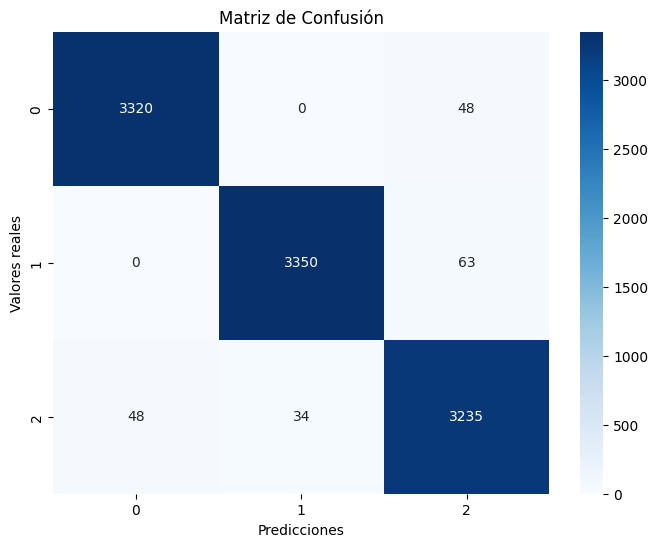

In [24]:
y_pred = modelo.predict(X_test)

print("Precisión:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

# Crear el heatmap de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.title('Matriz de Confusión')
plt.show()

In [25]:
len(y_test), cont.sum()

(10098, np.int64(50488))

En base a la matriz de confusión, lo que podemos notar es que la clasificación de los datos en las categorias adecuadas es la correcta, segun su presentación encontramos:

- 3320 paises que se encuentran en el grupo de alta contaminación fueron clasificados correctamente mientras que 48 de ellos fueron clasificados erroneamente como bajos.

- 3350 paises que se encuentran en el grupo de contaminación media fueron clasificados correctamente mientras que 63 de ellos fueron clasificados erroneamente como de bajo impacto.

- 3235 paises de bajo impacto fueron correctamente clasificados como paises de bajo impacto mientras que 48 de ellos fueron clasificados erroneamente como paises de alto impacto y 34 como paises de medio impacto.
En el ultimo caso el modelo sobreestimo el impacto de los paises que en realidad tienen un riesgo bajo

+ La precisión es el porcentaje de predicciones correctas sobre el total de muestras evaluadas, la de este modelo es del 98%. Si miramos la de cada una de las categorias, le es mas facil esimar los extremos, aquellas categorias de alto o bajo impacto, mientras que la media es en la cual comete mayores errores y quiza se deba al metodo utilizado para cortar entre las diferentes categorias. Comprobaremos mas adelante su desempeño al utilizar el otro metodo de corte.

+ El Recall es una métrica que indica qué proporción de los casos positivos reales (o de una clase en particular) fueron correctamente identificados por el modelo. El recall mas alto se encuentra para los paises de mayor impacto ambiental, lo que presenta un beneficio ya que son los casos mas criticos.

+ El F1 score es una métrica que combina la precisión y el recall en un solo valor. Se calcula como la media armónica de la precisión y el recall, lo que significa que sólo obtendrá un valor alto cuando ambas métricas sean altas. En el caso de F1 el valor mas bajo pertenece a la clase media, lo que significa que su relacion entre precision y recall es la mas baja, lo que es un resultado a tener en cuenta.

+ El Support es el numero de ocurrencias para cada caso, lo que se puede observar es que para las categorias, la mayor ocurrencia es en las clases mas bajas, lo que se puede relacionar con la forma en la que qcut separa los datos en categorias en la misma cantidad de datos por grupo, por lo que si hay varios paises en la misma linea, en normal que el modelo tenga confusiones al clasificarlos.

##Buscamos los mejores hiperparametros:
Los hiperparámetros son las configuraciones previas al entrenamiento.
Luego de entrenar el modelo base de Random Forest, realizamos un proceso de optimización de hiperparámetros con el objetivo de mejorar su rendimiento. Para esto utilizamos la técnica de búsqueda aleatoria (RandomizedSearchCV), que permite explorar distintas combinaciones de parámetros sin necesidad de evaluar todas las posibles, lo cual hace el proceso más eficiente.

In [26]:
from sklearn.ensemble import RandomForestClassifier


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': False}
Precisión: 0.9809863339275104
              precision    recall  f1-score   support

        Alto       0.99      0.99      0.99      3368
        Bajo       0.99      0.98      0.98      3413
       Medio       0.97      0.98      0.97      3317

    accuracy                           0.98     10098
   macro avg       0.98      0.98      0.98     10098
weighted avg       0.98      0.98      0.98     10098



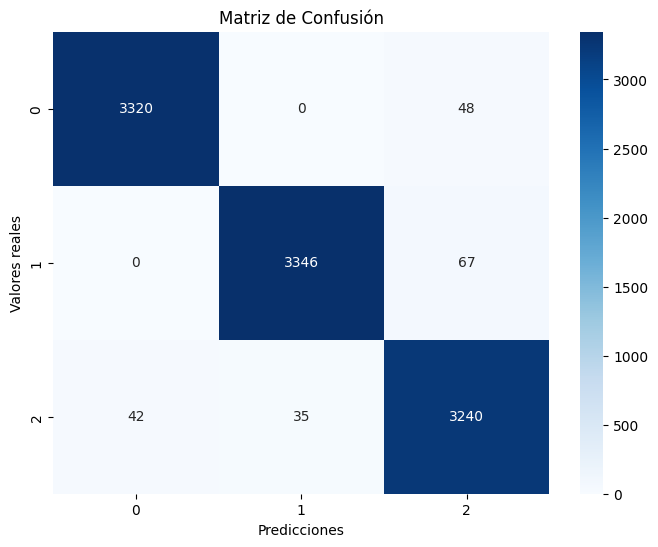

In [27]:
from sklearn.model_selection import RandomizedSearchCV

# Definimos el modelo base
modelo_rf = RandomForestClassifier(random_state=42)

# Espacio de búsqueda
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=modelo_rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento con optimización
random_search.fit(X_train, y_train)

# Evaluación
mejor_modelo = random_search.best_estimator_
y_pred_opt = mejor_modelo.predict(X_test)

print("Mejores hiperparámetros:", random_search.best_params_)
print("Precisión:", accuracy_score(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))


# Crear el heatmap de la matriz de confusión
cmopt = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(8, 6))
sns.heatmap(cmopt, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.title('Matriz de Confusión')
plt.show()

Se observa una disminución en la cantidad de paises de bajo impacto clasificados como de alto impacto, pero uamento la cantidad de paises de medio impacto clasificados como de bajo impacto. Aun asi, la diferencia entre el modelo estandar y el optimizado no es simbólica.

###Comparación con otro modelo

Comparación con otro modelo (Logistic Regression)
Para evaluar el rendimiento de nuestro modelo Random Forest, decidimos compararlo con una alternativa más sencilla y clásica: la regresión logística. Entrenamos este modelo base utilizando los mismos datos de entrenamiento, ajustando el parámetro max_iter=1000 para asegurar que el algoritmo convergiera correctamente. Luego, predecimos los valores del conjunto de testeo y calculamos su precisión mediante accuracy_score, además de generar un informe detallado con classification_report.

Regresión Logística - Precisión: 0.998613586848881
              precision    recall  f1-score   support

        Alto       1.00      1.00      1.00      3368
        Bajo       1.00      1.00      1.00      3413
       Medio       1.00      1.00      1.00      3317

    accuracy                           1.00     10098
   macro avg       1.00      1.00      1.00     10098
weighted avg       1.00      1.00      1.00     10098



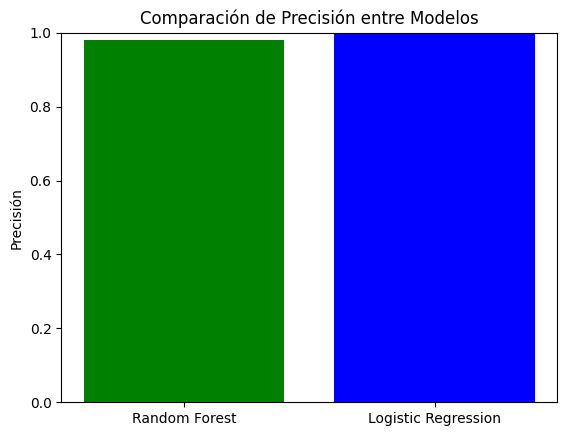

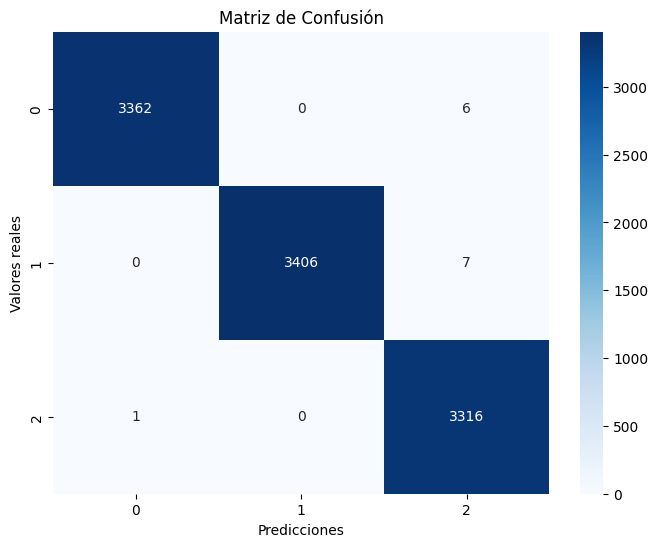

In [28]:

from sklearn.linear_model import LogisticRegression

# Entrenamos un modelo base de regresión logística
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

print("Regresión Logística - Precisión:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Comparación visual de precisión
from matplotlib import pyplot as plt

accuracy_rf = accuracy_score(y_test, y_pred_opt)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

plt.bar(['Random Forest', 'Logistic Regression'], [accuracy_rf, accuracy_lr], color=['green', 'blue'])
plt.ylabel('Precisión')
plt.title('Comparación de Precisión entre Modelos')
plt.ylim(0, 1)
plt.show()


# Crear el heatmap de la matriz de confusión
cmlr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cmlr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.title('Matriz de Confusión')
plt.show()

La regresión logica presenta mejores resultados, la mayoria de los datos fueron claificados correctamente, por lo que se podria decir que es mejor clasificador para nuestros datos.

###Importancia de las variables

**Importancia de variables (feature importances)**
Una vez identificado el mejor modelo mediante la búsqueda de hiperparámetros, quisimos entender cómo tomaba decisiones. Para eso, analizamos la importancia de las variables utilizando el atributo feature_importances_ de nuestro RandomForestClassifier. Esta propiedad nos devuelve un valor numérico para cada variable que indica cuánto aporta al rendimiento del modelo.

<ipython-input-17-240787120>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette="viridis")


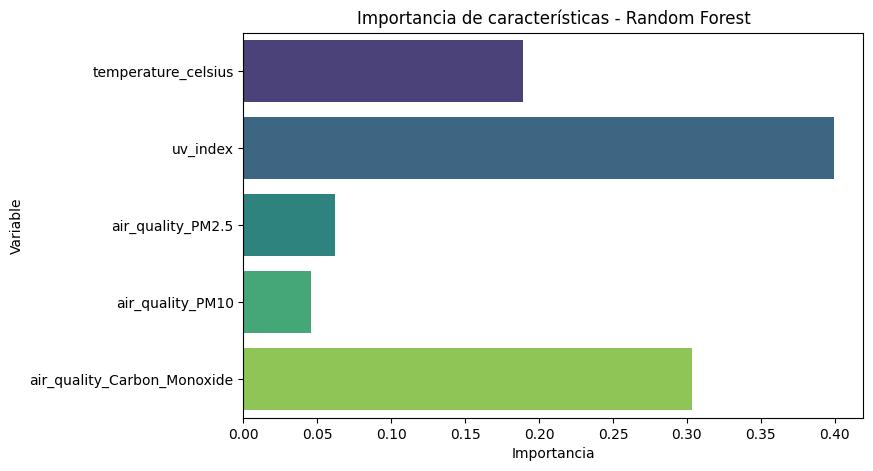

In [ ]:
# Importancia de variables en Random Forest
importances = mejor_modelo.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names, palette="viridis")
plt.title("Importancia de características - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred_lr)

# Crear el heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

Como se puede observar, se prioriza el impacto de los rayos UV y la cantidad de monoxido de carbono a la hora de clasificar a los paises